In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")
from transformers import (
AutoModel,
AutoTokenizer,
DataCollatorWithPadding,
)
import numpy as np
import datasets
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from huggingface_hub import login
from tqdm import tqdm

# Метрики обучения Phi-3

In [2]:
df = pd.read_json('/kaggle/input/models/dmytriypan/phi-3-classificator/transformers/llm_classificator/1/trainer_state_manual.json')
df

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.190486,72.372131,1.901600e-05,0.004861,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.760108,45.442883,1.802000e-05,0.009722,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,0.009722,500,0.294884,0.8860,0.916667,0.888176,0.902196,548.8585,9.110,4.555,NaN,NaN,NaN,NaN,NaN
3,0.499075,5.548698,1.702000e-05,0.014583,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.635997,21.729708,1.602400e-05,0.019444,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,0.019444,1000,0.331266,0.9184,0.982602,0.877703,0.927195,547.4924,9.133,4.566,NaN,NaN,NaN,NaN,NaN
6,0.580329,62.717083,1.502400e-05,0.024305,1250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.592109,3.501951,1.402400e-05,0.029166,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,0.029166,1500,0.266158,0.9306,0.955385,0.926014,0.940470,547.4164,9.134,4.567,NaN,NaN,NaN,NaN,NaN
9,0.528076,9.570814,1.302400e-05,0.034027,1750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_train = df[df['loss'].notna()]

df_valid = df[(df['eval_loss'].notna())]
df_metrics = df[['eval_accuracy', 'eval_precision', 'eval_recall', 'eval_f1', 'step']]

In [4]:
df_valid

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
2,NaN,NaN,NaN,0.009722,500,0.294884,0.8860,0.916667,0.888176,0.902196,548.8585,9.110,4.555,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,0.019444,1000,0.331266,0.9184,0.982602,0.877703,0.927195,547.4924,9.133,4.566,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,0.029166,1500,0.266158,0.9306,0.955385,0.926014,0.940470,547.4164,9.134,4.567,NaN,NaN,NaN,NaN,NaN
11,NaN,NaN,NaN,0.038888,2000,0.253230,0.9364,0.958362,0.933108,0.945567,546.6790,9.146,4.573,NaN,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,0.048610,2500,0.235971,0.9390,0.976661,0.918919,0.946910,548.1591,9.121,4.561,NaN,NaN,NaN,NaN,NaN
17,NaN,NaN,NaN,0.058332,3000,0.226254,0.9420,0.974414,0.926351,0.949775,547.1538,9.138,4.569,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,0.068054,3500,0.243529,0.9410,0.976063,0.922973,0.948776,547.1783,9.138,4.569,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,0.077776,4000,0.232116,0.9440,0.976868,0.927365,0.951473,547.6501,9.130,4.565,NaN,NaN,NaN,NaN,NaN
26,NaN,NaN,NaN,0.087498,4500,0.226824,0.9438,0.968193,0.935811,0.951727,547.4160,9.134,4.567,NaN,NaN,NaN,NaN,NaN
29,NaN,NaN,NaN,0.097220,5000,0.226118,0.9452,0.969580,0.936824,0.952921,548.0882,9.123,4.561,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_22/2582067070.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


eval_accuracy
eval_precision
eval_recall
eval_f1


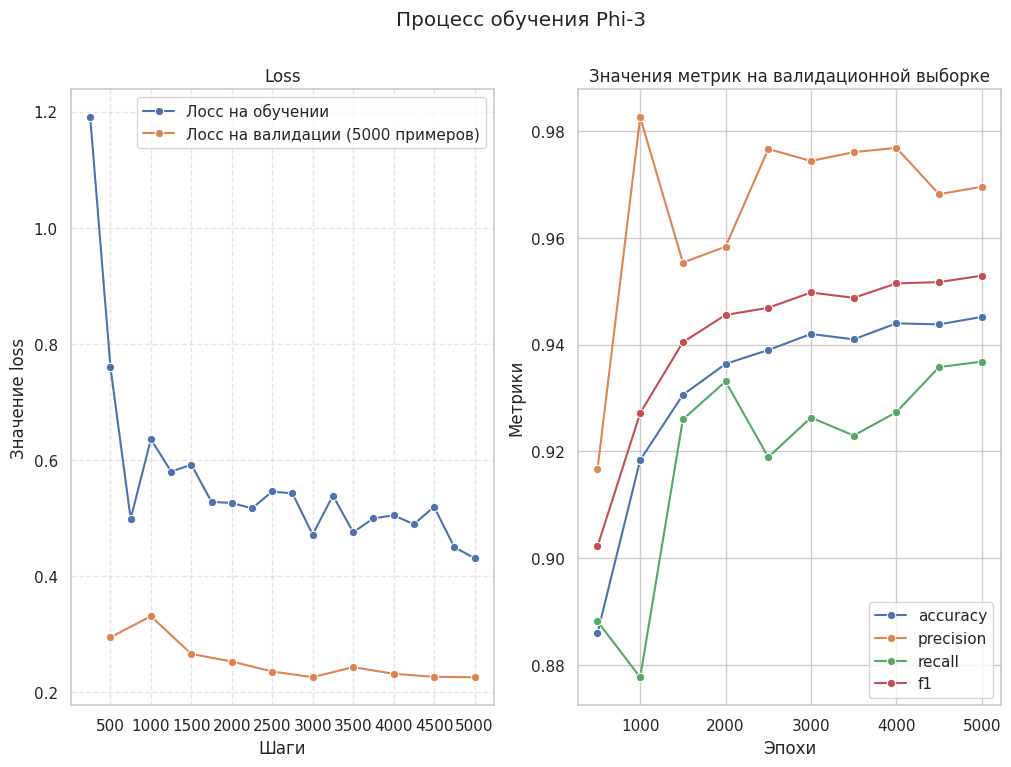

In [5]:
num_steps = df_valid['step']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))
plt.suptitle('Процесс обучения Phi-3')
ax[0].set_title('Loss')
ax[0].set_xlabel('Шаги')
ax[0].set_ylabel('Значение loss')

sns.lineplot(x=df_train['step'], y=df_train['loss'], label='Лосс на обучении', ax=ax[0], marker='o', )
ax[0].xaxis.set_major_locator(ticker.MultipleLocator(500))
ax[0].grid(True, which='major', linestyle='--', alpha=0.5)
sns.lineplot(x=df_valid['step'], y=df_valid['eval_loss'], label='Лосс на валидации (5000 примеров)', ax=ax[0], marker='o', )


ax[1].set_xlabel('Эпохи')
ax[1].set_ylabel('Метрики')
ax[1].set_title('Значения метрик на валидационной выборке')
# ax[1].plot('epoch','eval_accuracy', data=df_eval_metrics)
ax[1].legend()
for metric in df_metrics.drop(['step'], axis=1).columns:
    print(metric)
    sns.lineplot(ax=ax[1], x=df_metrics['step'], y=df_metrics[metric], label=metric[5:], marker='o')

plt.savefig('loss and metrics.png')

# Класс классификатора

In [6]:
class LLM_Classificator(nn.Module):
    """
    Классификатор текста на основе LLM
    """
    
    def __init__(self, base_model, tokenizer, num_labels=2):
        super().__init__()
        self.base_model = base_model
        self.tokenizer = tokenizer
        self.num_labels = num_labels
        # self.cls_tok_id = tokenizer.convert_tokens_to_ids('[CLS]')
        self.classification_head = nn.Linear(base_model.config.hidden_size, 
                                             num_labels, 
                                             # dtype=torch.float16
                                            ).to(base_model.device)
        self.loss_func = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask, labels=None, **kwargs):
        # print(f"DEBUG: keys in batch: {kwargs.keys()}")
        outputs = self.base_model(
            input_ids=input_ids, 
            attention_mask=attention_mask,
            output_hidden_states=False,
            use_cache=False,
            **kwargs
        )
        # берем последнее состояние контекста
        last_hidden_state = outputs.last_hidden_state
        # извлекаем эмбеддинг для последнего токена
        last_token_embed = last_hidden_state[:, -1, :]
        last_token_embed = last_token_embed.to(self.classification_head.weight.dtype)
        # print(last_token_embed.device, last_token_embed.dtype)
        # прогоняем эмбеддинг последнего токена через слой классификатора
        logits = self.classification_head(last_token_embed)
        # loss = None

        if labels is not None:
            # loss_func = nn.CrossEntropyLoss()
            loss = self.loss_func(logits.view(-1, self.num_labels), labels.view(-1)) # считаем loss score для батча
        
        return {'logits': logits, 'loss': loss}

    @property
    def device(self):
        return next(self.parameters()).device

# Загрузка модели

In [7]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
if hf_token:
    print('авторизация на Hugging Face...')
    login(hf_token)
    print('авторизация на Hugging Face прошла успешно!')
else:
    print('Токен не найден')
    
ds = datasets.load_dataset("iitolstykh/LLMTrace_classification")
print('Данные загружены')

авторизация на Hugging Face...
авторизация на Hugging Face прошла успешно!


README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/1.40G [00:00<?, ?B/s]

valid.jsonl:   0%|          | 0.00/292M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/318M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/411440 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/86696 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/90950 [00:00<?, ? examples/s]

Данные загружены


In [8]:
MODEL_PATH = '/kaggle/input/models/dmytriypan/phi-3-classificator/transformers/llm_classificator/1/phi3_final_merged'
HEAD_WEIGHTS_PATH = '/kaggle/input/models/dmytriypan/phi-3-classificator/transformers/llm_classificator/1/phi3_final_merged/classification_head.pth'
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Текущий девайс: {device}')

phi_3 = AutoModel.from_pretrained(MODEL_PATH)
print(phi_3)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
classificator = LLM_Classificator(base_model=phi_3, tokenizer=tokenizer, num_labels=2)
print('='*50)
print(classificator)
classificator.classification_head.half()
state_dict = torch.load_state_dict = torch.load(HEAD_WEIGHTS_PATH, map_location=device)
classificator.classification_head.load_state_dict(state_dict)
print(classificator.classification_head.weight.dtype)

Текущий девайс: cuda:0


Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

Phi3Model(
  (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
  (layers): ModuleList(
    (0-31): 32 x Phi3DecoderLayer(
      (self_attn): Phi3Attention(
        (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
      )
      (mlp): Phi3MLP(
        (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
        (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
        (activation_fn): SiLUActivation()
      )
      (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
      (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
      (resid_attn_dropout): Dropout(p=0.0, inplace=False)
      (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (norm): Phi3RMSNorm((3072,), eps=1e-05)
  (rotary_emb): Phi3RotaryEmbedding()
)
LLM_Classificator(
  (base_model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (layer

In [9]:
classificator.to(device)

LLM_Classificator(
  (base_model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (classification_head): Linear(in_featur

In [10]:
devices = {param.device for param in classificator.parameters()}
print(devices)

{device(type='cuda', index=0)}


# Функция для токенизации

In [11]:
import typing
from typing import Dict, Any
label2id = {'ai': 0, 'human': 1}
def tokenize_examples(examples: Dict[str, Any]) -> Dict[str, Any]:
    """
    Функция токенизации
    --------------------------
    Parameters:
    example : datasets.DatasetDict
        датасет из библиотеки HF Datasets

     Returns:
    --------
    datasets.DatasetDict
        Токенизированный датасет
    """
    result = tokenizer(examples['text'], truncation = True, max_length = 256,)
    result['label'] = [label2id[l] for l in examples['label']]
    return result

# Предобработка данных

In [12]:
ds_test = ds['test']
# print(np.unique(ds_test['label']))

In [13]:
ds_test_tokenized = ds_test.map(tokenize_examples, batched=True)

Map:   0%|          | 0/90950 [00:00<?, ? examples/s]

# Инференс на тесте

In [14]:
# Инференс модели на тесте.

inputs = ds_test_tokenized.select_columns(['input_ids', 'attention_mask', 'label'])
test_loader = DataLoader(inputs, 
                         batch_size=32, 
                         shuffle=False, 
                         collate_fn=DataCollatorWithPadding(tokenizer=tokenizer,)
                        )

all_labels = []
all_loss = []
all_predicts = []
all_probs = []
with torch.inference_mode():
    for batch in tqdm(test_loader, desc='Test'):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = classificator(**batch)
        logits, loss = out['logits'], out['loss']
        # print(loss)

        all_loss.append(loss.item())
        # print(all_loss)
        
        probs = nn.functional.softmax(logits, dim=-1)
        all_probs.extend(probs.cpu().numpy().tolist())
        preds = torch.argmax(probs, dim=-1).cpu().numpy().tolist()
        all_predicts.extend(preds)
        # print(all_predicts)

        all_labels.extend(batch['labels'].cpu().numpy().tolist())
        # print(all_labels)

Test: 100%|██████████| 2843/2843 [3:16:20<00:00,  4.14s/it]


# Анализ результатов

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_true=all_labels, y_pred=all_predicts))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     54484
           1       0.90      0.95      0.93     36466

    accuracy                           0.94     90950
   macro avg       0.94      0.94      0.94     90950
weighted avg       0.94      0.94      0.94     90950



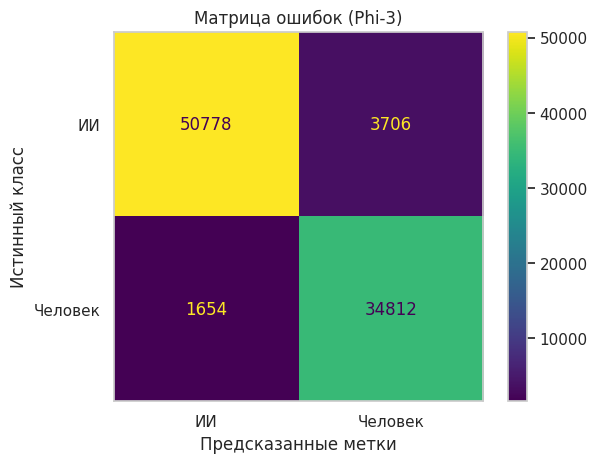

In [16]:
conf_mat = confusion_matrix(all_labels, all_predicts)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=['ИИ', 'Человек'])
disp.plot()
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (Phi-3)')
plt.grid(False)
plt.savefig(f'phi-3_confusion_matrix.png')
plt.show()

In [17]:
results_df = pd.DataFrame({
    'text' : ds_test['text'][:len(all_predicts)],
    'length' : [len(text) for text in ds_test['text'][:len(all_predicts)]],
    'label': ds_test['label'][:len(all_predicts)],
    'predict': ['ai' if label==0 else 'human' for label in all_predicts],
    'ai_prob' : [round(prob[0],4) for prob in all_probs],
    'human_prob' : [round(prob[1],4) for prob in all_probs],
})
results_df

,text,length,label,predict,ai_prob,human_prob
0,"Купонная доходность – это доходность, которую ...",1356,ai,ai,1.0000,0.0002
1,Можно ли полностью защититься от кибератак? На...,13138,human,human,0.0075,0.9927
2,Жаркое лето - ее бы на руки. Поцеловать бы при...,212,human,human,0.0014,0.9985
3,Исламская организация ИСЕСКО призывает междуна...,614,ai,ai,1.0000,0.0000
4,Украинские власти отказались пропустить гумани...,1633,human,human,0.0030,0.9971
...,...,...,...,...,...,...
90945,"- Information gathering is crucial, but it's a...",820,ai,ai,1.0000,0.0000
90946,The deepest freshwater lake in the world is La...,2425,ai,ai,1.0000,0.0000
90947,The article highlights the challenges of deali...,111,ai,ai,0.9995,0.0003
90948,The cases involve 165 suspects and more than 1...,591,human,human,0.0021,0.9980


In [18]:
errors_df = results_df[results_df['label'] != results_df['predict']]
errors_df.reset_index(drop=True, inplace=True)
display(errors_df.head())

,text,length,label,predict,ai_prob,human_prob
0,"В конце лестницы была дверь, не очень плотно з...",8676,human,ai,0.9565,0.0435
1,В современной исторической науке принято обозн...,1294,human,ai,0.9619,0.0383
2,"Что видим мы. Теперь нравоученьяДля ""интеллект...",1038,ai,human,0.0019,0.9980
3,"того, здесь нет дорог, поэтому грузовики выво...",496,ai,human,0.2935,0.7065
4,Мощный взрыв на нефтепроводе в Мексике унес жи...,3059,human,ai,0.9971,0.0031


In [19]:
def print_random_errors(df, num_errors=20):
    print(f"{'='*40}")
    print(f" АНАЛИЗ СЛУЧАЙНЫХ ОШИБОК ({num_errors} примеров)")
    print(f"{'='*40}\n")
    
    id2label = {0: "AI", 1: "Human"}
    
    actual_num = min(len(df), num_errors)
    sample_df = df.sample(n=actual_num).reset_index(drop=False) # сохраняем старый индекс для инфы
    
    for i in range(actual_num):
        row = sample_df.iloc[i]
        true_lab = id2label.get(row['label'], row['label'])
        pred_lab = id2label.get(row['predict'], row['predict'])
        
        print(f"ОШИБКА #{i+1} (Индекс в тесте: {row['index']})")
        print(f"  Ожидание: {true_lab}")
        print(f"  Реальность: {pred_lab}")
        # Округлим вероятности для читаемости
        print(f"  Уверенность AI: {row['ai_prob']:.4f}")
        print(f"  Уверенность Human: {row['human_prob']:.4f}")
        
        print("-" * 15)
        
        clean_text = " ".join(str(row['text']).split())
        print(f"  Текст: {clean_text[:1000]}...")
        print("\n" + "="*80 + "\n")

print_random_errors(errors_df, 20)

 АНАЛИЗ СЛУЧАЙНЫХ ОШИБОК (20 примеров)

ОШИБКА #1 (Индекс в тесте: 3210)
  Ожидание: ai
  Реальность: human
  Уверенность AI: 0.0040
  Уверенность Human: 0.9961
---------------
  Текст: Всегда много народу..... если заранее не зарезервировать столик по телефону, шансы попасть в ресторанчик резко снижаются к нулю..... Интерьер.... мило.... по - студенчески забавно.... 16929854 vetana 2007-03-12 20:33:00 Подумалось тут, а как вы относитесь к людям, которые ведут себя так, будто они ничего не знают о том, что происходит вокруг них? 16929855 vetana 2007-03-12 19:41:00 А я все думала, почему у меня на работе (в частности) нет кофеварки. И вот вспомнила про нее. 16929856 vetana 2007-03-11 22:44:00 Сходили с на "Дневник Бриджит Джонс" 16929857 vetana 2007-03-11 21:40:00 В выходные сходили в кино. Фильм очень понравился. Я бы сказала, что это лучший фильм из всех, что я видела. В нем есть какая-то изюминка, которая заставляет смотреть и пересматривать его снова и снова. Ну может быть потому, ч

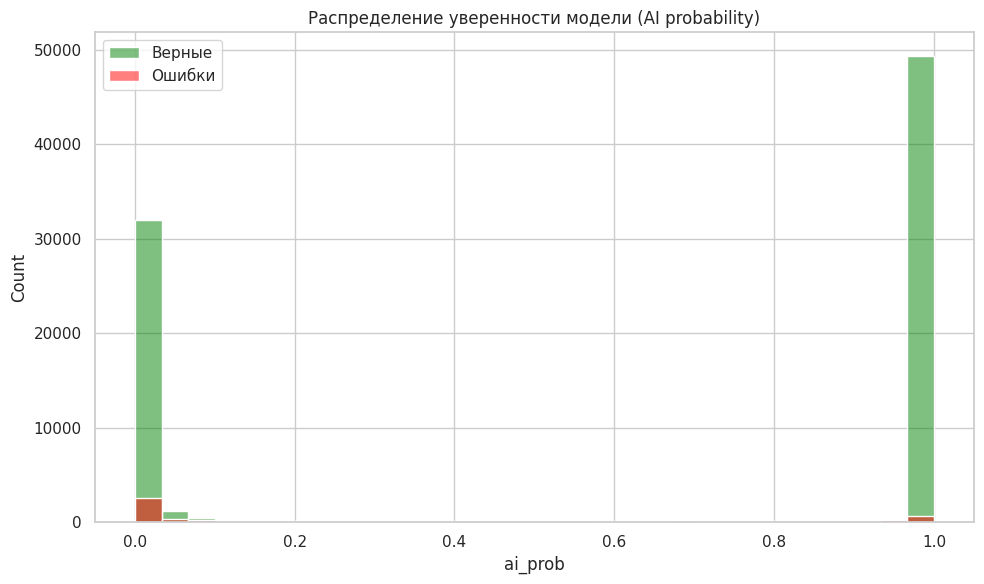

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=results_df[results_df['label'] == results_df['predict']], x='ai_prob', label='Верные', color='green', alpha=0.5, bins=30)
sns.histplot(data=results_df[results_df['label'] != results_df['predict']], x='ai_prob', label='Ошибки', color='red', alpha=0.5, bins=30)
plt.title('Распределение уверенности модели (AI probability)')
plt.legend()
plt.tight_layout()
plt.savefig('Уверенность phi-3.png')
plt.show()

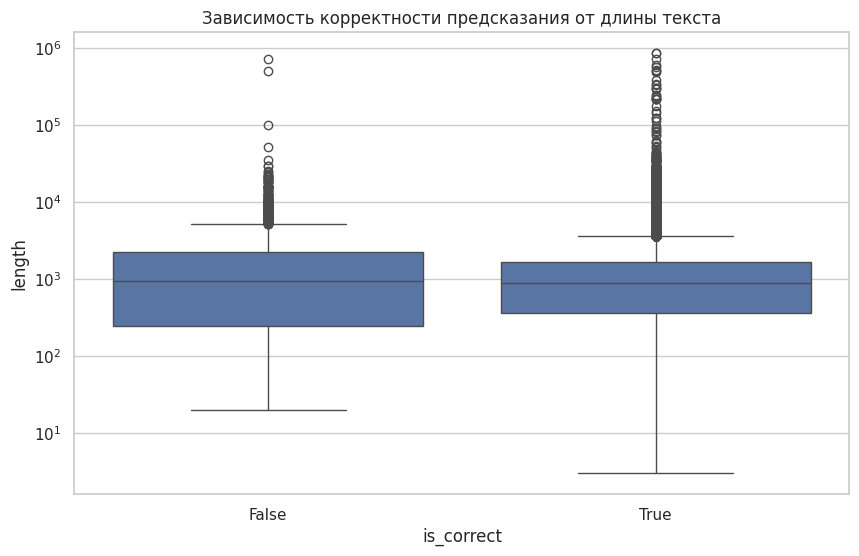

In [21]:
results_df['is_correct'] = results_df['label'] == results_df['predict']
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_correct', y='length', data=results_df)
plt.yscale('log') # логарифмическая шкала, если разброс длин большой
plt.title('Зависимость корректности предсказания от длины текста')
plt.savefig("boxplot.png")
plt.show()

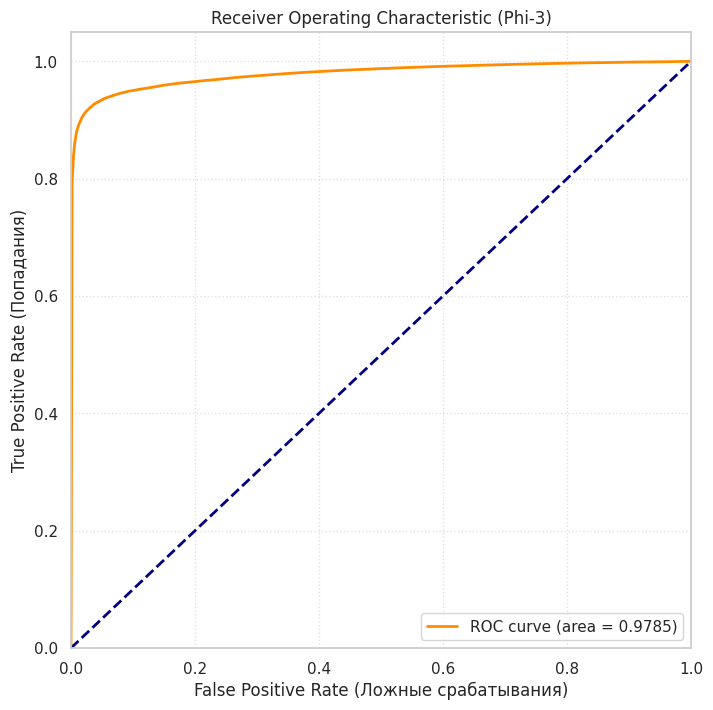

In [22]:
from sklearn.metrics import roc_curve, auc

# 1. Готовим данные
# all_labels у нас уже [0, 1, ...], а вероятности берем для класса 'human' (индекс 1)
fpr, tpr, thresholds = roc_curve(all_labels, [p[0] for p in all_probs], pos_label=0)
roc_auc = auc(fpr, tpr)

# 2. Визуализация
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Линия случайного угадывания

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Попадания)')
plt.title('Receiver Operating Characteristic (Phi-3)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('ROC-AUC.png')
plt.show()

In [23]:
# Вычисляем G-mean для каждого порога
gmeans = np.sqrt(tpr * (1 - fpr))
ix = np.argmax(gmeans)
print(f'Лучший порог по G-Mean: {thresholds[ix]:.4f}, G-Mean: {gmeans[ix]:.4f}')

Лучший порог по G-Mean: 0.8369, G-Mean: 0.9449


In [24]:
new_threshold = thresholds[ix]

results_df['new_predict'] = ['human' if p >= new_threshold else 'ai' for p in results_df['human_prob']]
print(classification_report(results_df['label'], results_df['new_predict']))

              precision    recall  f1-score   support

          ai       0.95      0.94      0.95     54484
       human       0.91      0.93      0.92     36466

    accuracy                           0.94     90950
   macro avg       0.93      0.94      0.94     90950
weighted avg       0.94      0.94      0.94     90950



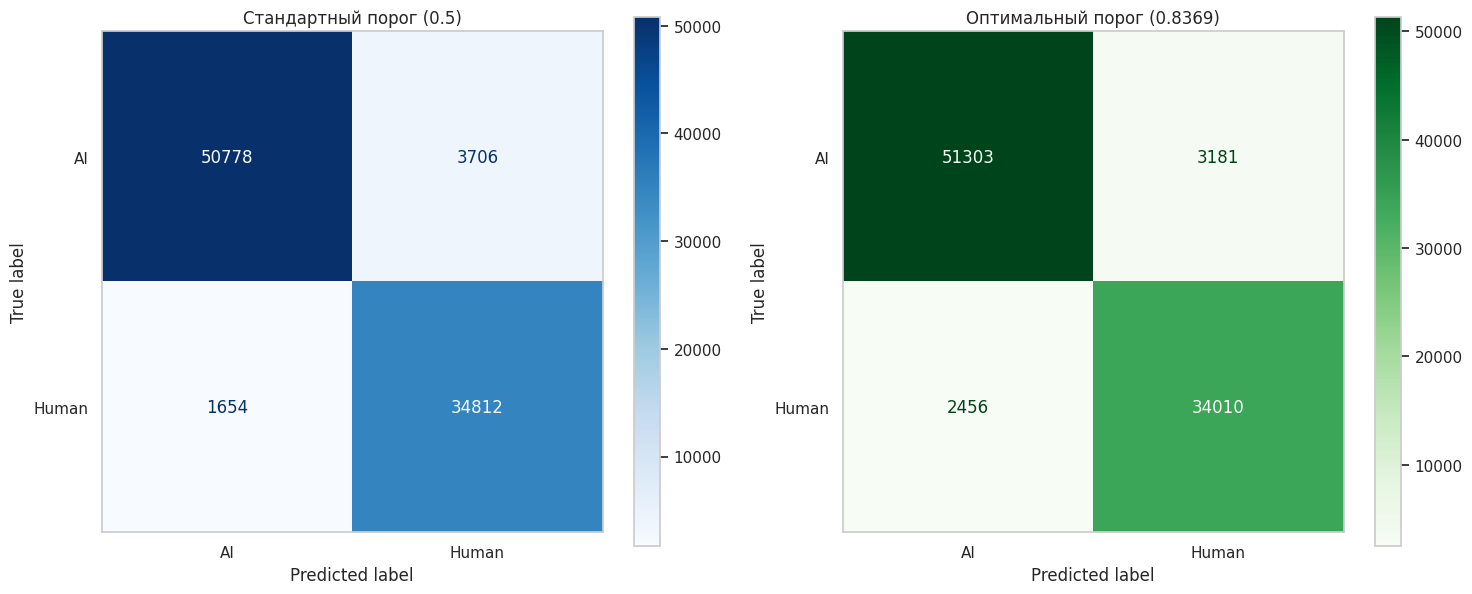

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Матрица для стандартного порога 0.5
cm_old = confusion_matrix(results_df['label'], results_df['predict'])
disp_old = ConfusionMatrixDisplay(cm_old, display_labels=['AI', 'Human'])
disp_old.plot(ax=ax[0], cmap='Blues')
plt.grid(False)
ax[0].set_title('Стандартный порог (0.5)')
ax[0].grid(False)
# Матрица для нового порога (G-Mean)
cm_new = confusion_matrix(results_df['label'], results_df['new_predict'])
disp_new = ConfusionMatrixDisplay(cm_new, display_labels=['AI', 'Human'])
disp_new.plot(ax=ax[1], cmap='Greens')
ax[1].set_title(f'Оптимальный порог ({new_threshold:.4f})')
ax[1].grid(False)
plt.tight_layout()
plt.savefig('threshold_comparison.png')
plt.show()

In [26]:
results_df.to_csv('phi3_test_results_full.csv', index=False)
errors_df.to_csv('phi3_errors_only.csv', index=False)